# ATP Tennis Match Prediction — Exploratory Data Analysis

**Group 8** — IE University, MsC Business Analytics & Data Science, MLOps 2026

This notebook explores the ATP tennis match dataset and demonstrates the production pipeline modules. All data loading, cleaning, and feature engineering is done via the same `src/` modules used in the live API.

---

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 12})

print("Setup complete.")

Setup complete.


## 1. Load Raw Data

We use `src.load_data.load_raw_data` to load 6 seasons of ATP match data (2018-2023) from cached local files.

In [2]:
from pathlib import Path
import yaml

with open("../config.yaml") as f:
    config = yaml.safe_load(f)

from src.load_data import load_raw_data

raw_dir = Path("../" + config["paths"]["raw_dir"])
base_url = config["dataset"]["base_url"]
all_seasons = (
    config["dataset"]["seasons_train"]
    + config["dataset"]["seasons_val"]
    + config["dataset"]["seasons_test"]
    + config["dataset"]["seasons_infer"]
)

df_raw = load_raw_data(raw_dir, base_url, all_seasons, download_if_missing=True)
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

2026-03-27 22:48:12,502 | INFO | src.load_data | Attempting to load raw data for seasons [2018, 2019, 2020, 2021, 2022, 2023] from ../data/raw ...
2026-03-27 22:48:12,503 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2018.csv ...
2026-03-27 22:48:12,510 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2019.csv ...
2026-03-27 22:48:12,516 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2020.csv ...
2026-03-27 22:48:12,523 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2021.csv ...
2026-03-27 22:48:12,528 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2022.csv ...
2026-03-27 22:48:12,534 | INFO | src.utils | Loading CSV from ../data/raw/atp_matches_2023.csv ...
2026-03-27 22:48:12,542 | INFO | src.load_data | Loaded 15801 records across 6 seasons.
Raw dataset: 15,801 rows x 49 columns


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2018-M020,Brisbane,Hard,32,A,20180101,271,105992,NaN,NaN,...,47.0,33.0,19.0,14.0,1.0,4.0,47.0,1010.0,52.0,909.0
1,2018-M020,Brisbane,Hard,32,A,20180101,272,111577,NaN,NaN,...,41.0,25.0,7.0,9.0,7.0,11.0,54.0,890.0,94.0,593.0
2,2018-M020,Brisbane,Hard,32,A,20180101,273,104797,NaN,NaN,...,53.0,37.0,29.0,15.0,10.0,16.0,63.0,809.0,30.0,1391.0
3,2018-M020,Brisbane,Hard,32,A,20180101,275,200282,NaN,WC,...,43.0,33.0,17.0,11.0,4.0,6.0,208.0,245.0,44.0,1055.0
4,2018-M020,Brisbane,Hard,32,A,20180101,276,111581,NaN,Q,...,35.0,28.0,5.0,9.0,0.0,2.0,175.0,299.0,68.0,755.0


## 2. Clean Data

Using `src.clean_data.clean_dataframe` — standardises columns, removes duplicates, parses dates, imputes missing ranks.

In [3]:
from src.clean_data import clean_dataframe

target = config["schema"]["target"]
df_clean = clean_dataframe(df_raw, target)
print(f"Clean dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Dropped {df_raw.shape[0] - df_clean.shape[0]} rows during cleaning")

2026-03-27 22:48:12,555 | INFO | src.clean_data | Cleaning raw dataframe ...
2026-03-27 22:48:12,572 | INFO | src.clean_data | Cleaning complete: 15801 -> 15748 rows (dropped 53)
Clean dataset: 15,748 rows x 49 columns
Dropped 53 rows during cleaning


## 3. Dataset Overview

In [4]:
print("=== Column Types ===")
print(df_clean.dtypes.value_counts())
print(f"\nTotal missing values: {df_clean.isnull().sum().sum():,}")
print(f"\nDate range: {df_clean['tourney_date'].min()} to {df_clean['tourney_date'].max()}")

=== Column Types ===
float64           29
object            14
int64              5
datetime64[ns]     1
Name: count, dtype: int64

Total missing values: 58,204

Date range: 2018-01-01 00:00:00 to 2023-11-27 00:00:00


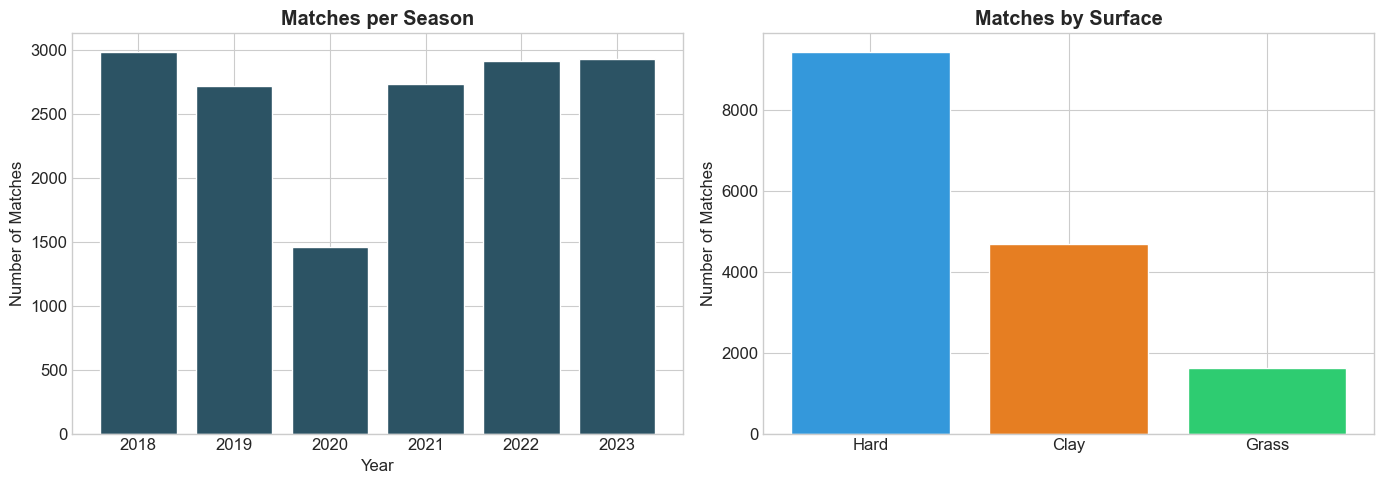

In [5]:
df_clean["year"] = df_clean["tourney_date"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

matches_by_year = df_clean["year"].value_counts().sort_index()
axes[0].bar(matches_by_year.index, matches_by_year.values, color="#2c5364", edgecolor="white")
axes[0].set_title("Matches per Season", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Matches")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

surface_counts = df_clean["surface"].value_counts()
colors = {"Hard": "#3498db", "Clay": "#e67e22", "Grass": "#2ecc71"}
bar_colors = [colors.get(s, "#95a5a6") for s in surface_counts.index]
axes[1].bar(surface_counts.index, surface_counts.values, color=bar_colors, edgecolor="white")
axes[1].set_title("Matches by Surface", fontweight="bold")
axes[1].set_ylabel("Number of Matches")

plt.tight_layout()
plt.show()

## 4. Ranking Distribution

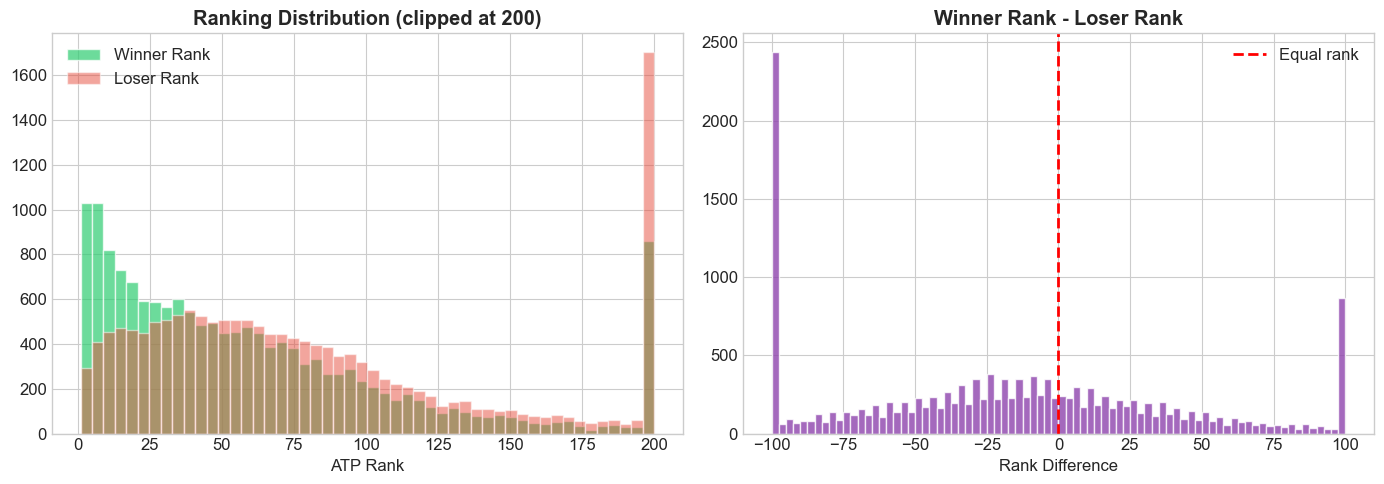

Higher-ranked player wins: 63.6% of the time
This is our baseline to beat.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["winner_rank"].clip(upper=200), bins=50, alpha=0.7,
             color="#2ecc71", label="Winner Rank", edgecolor="white")
axes[0].hist(df_clean["loser_rank"].clip(upper=200), bins=50, alpha=0.5,
             color="#e74c3c", label="Loser Rank", edgecolor="white")
axes[0].set_title("Ranking Distribution (clipped at 200)", fontweight="bold")
axes[0].set_xlabel("ATP Rank")
axes[0].legend()

rank_diff = df_clean["winner_rank"] - df_clean["loser_rank"]
axes[1].hist(rank_diff.clip(-100, 100), bins=80, color="#8e44ad", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Equal rank")
axes[1].set_title("Winner Rank - Loser Rank", fontweight="bold")
axes[1].set_xlabel("Rank Difference")
axes[1].legend()

plt.tight_layout()
plt.show()

higher_ranked_wins = (df_clean["winner_rank"] < df_clean["loser_rank"]).mean()
print(f"Higher-ranked player wins: {higher_ranked_wins:.1%} of the time")
print("This is our baseline to beat.")

## 5. Feature Engineering (Leakage-Free)

Using `src.features.build_features` — randomly assigns winner/loser to P1/P2 to prevent target leakage and ensure a balanced 50/50 target.

In [7]:
from src.features import build_features

X, y = build_features(df_clean)
print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")
print(f"\nFeatures: {list(X.columns)}")

Feature matrix: (15748, 15)
Target distribution:
player_1_win
1    0.501397
0    0.498603
Name: proportion, dtype: float64

Features: ['surface', 'draw_size', 'tourney_level', 'score', 'best_of', 'round', 'minutes', 'year', 'p1_rank', 'p2_rank', 'rank_diff', 'age_diff', 'ht_diff', 'p1_hand', 'p2_hand']


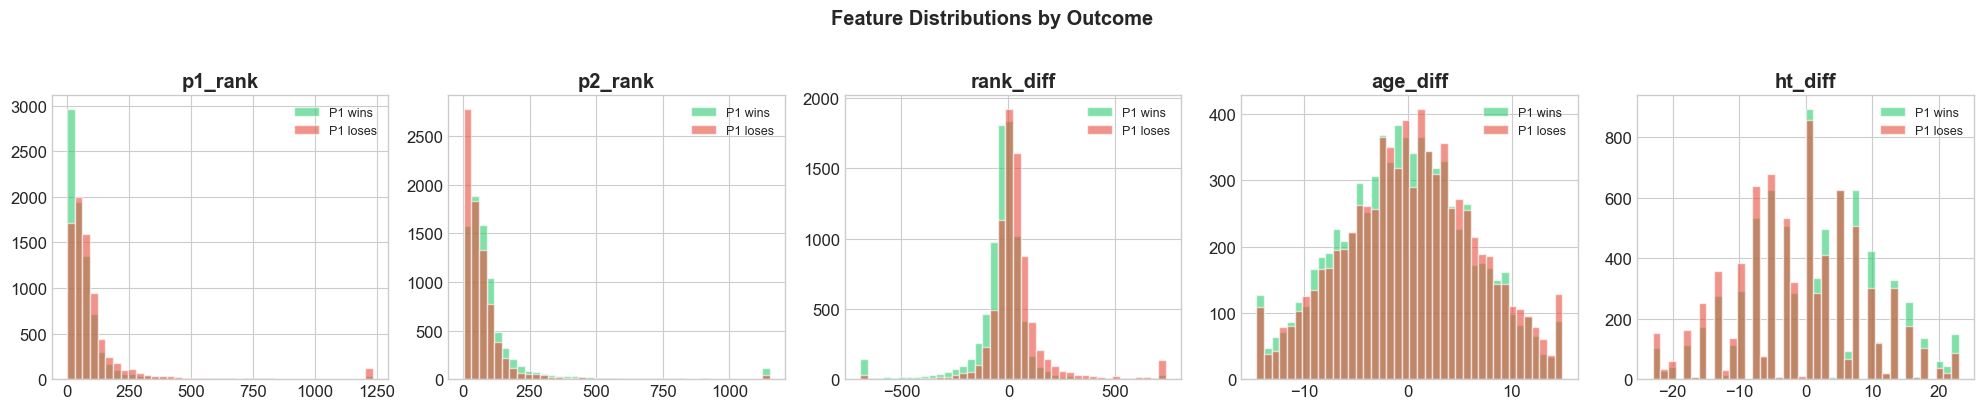

In [8]:
numeric_cols = ["p1_rank", "p2_rank", "rank_diff", "age_diff", "ht_diff"]
existing = [c for c in numeric_cols if c in X.columns]

fig, axes = plt.subplots(1, len(existing), figsize=(4 * len(existing), 4))
if len(existing) == 1:
    axes = [axes]

for ax, col in zip(axes, existing):
    for label, color in [(1, "#2ecc71"), (0, "#e74c3c")]:
        subset = X[y == label][col].dropna().clip(
            X[col].quantile(0.01), X[col].quantile(0.99)
        )
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f"P1 {'wins' if label == 1 else 'loses'}", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Feature Distributions by Outcome", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

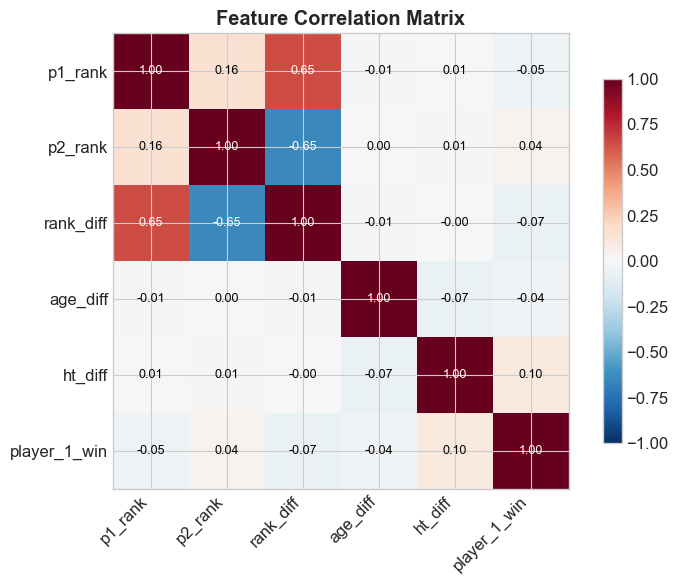

In [9]:
numeric_df = X[existing].copy()
numeric_df["player_1_win"] = y.values

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Train/Validation/Test Split

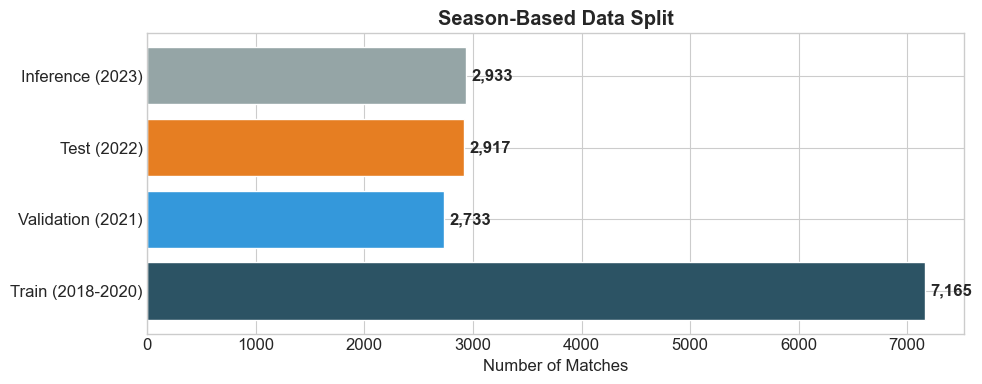

Split strategy: Temporal (by season) — no data leakage across time.


In [10]:
year_series = pd.to_datetime(df_clean["tourney_date"], format="mixed").dt.year

splits = {
    "Train (2018-2020)": df_clean[year_series.isin(config["dataset"]["seasons_train"])],
    "Validation (2021)": df_clean[year_series.isin(config["dataset"]["seasons_val"])],
    "Test (2022)": df_clean[year_series.isin(config["dataset"]["seasons_test"])],
    "Inference (2023)": df_clean[year_series.isin(config["dataset"]["seasons_infer"])],
}

split_sizes = {k: len(v) for k, v in splits.items()}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(split_sizes.keys()), list(split_sizes.values()),
               color=["#2c5364", "#3498db", "#e67e22", "#95a5a6"], edgecolor="white")
for bar, val in zip(bars, split_sizes.values()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontweight="bold")
ax.set_title("Season-Based Data Split", fontweight="bold")
ax.set_xlabel("Number of Matches")
plt.tight_layout()
plt.show()

print("Split strategy: Temporal (by season) — no data leakage across time.")

## 8. Surface Analysis

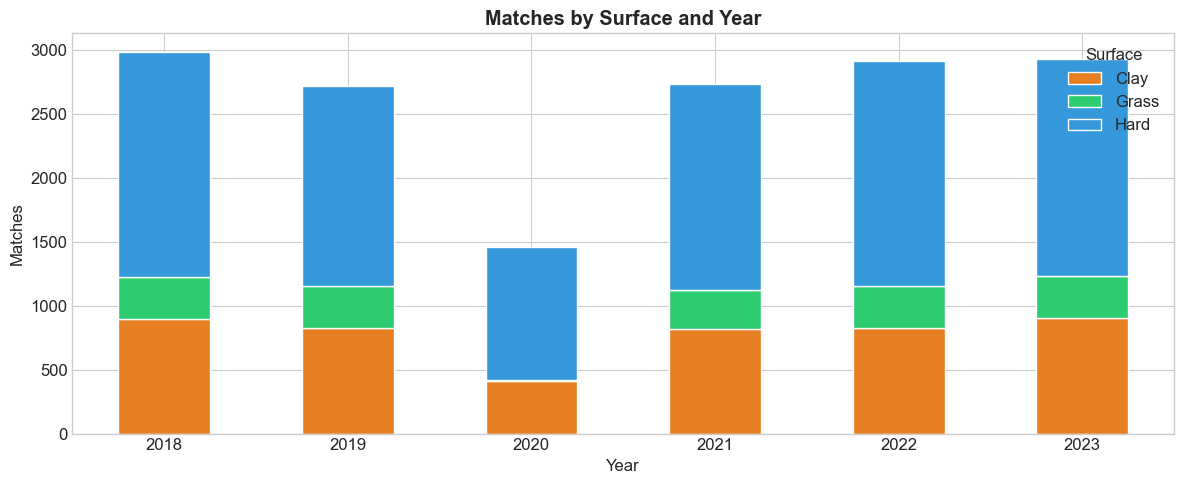

In [11]:
surface_year = df_clean.groupby(["year", "surface"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
surface_year.plot(kind="bar", stacked=True, ax=ax,
                  color=["#e67e22", "#2ecc71", "#3498db"], edgecolor="white")
ax.set_title("Matches by Surface and Year", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Matches")
ax.legend(title="Surface")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Model Performance vs Baseline

These are the metrics from our trained RandomForestClassifier compared to the rank-based heuristic baseline.

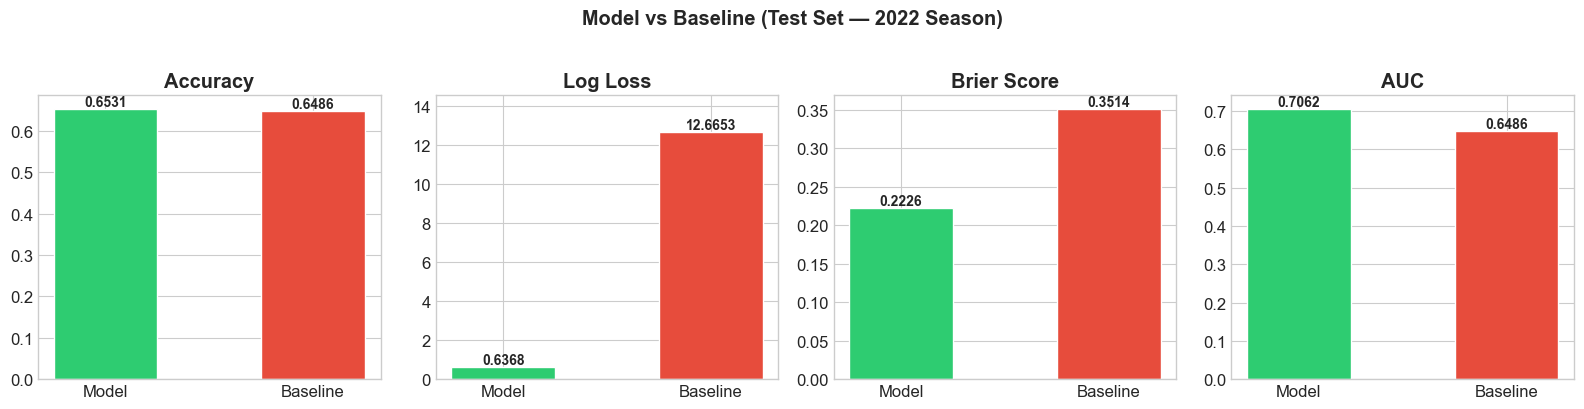

Key insight: While accuracy is only marginally better (+0.4pp),
log loss and brier score show DRAMATICALLY better probability calibration.
This is the real value — well-calibrated probabilities for decision-making.


In [12]:
metrics = {
    "Accuracy": {"Model": 0.6531, "Baseline": 0.6486},
    "Log Loss": {"Model": 0.6368, "Baseline": 12.6653},
    "Brier Score": {"Model": 0.2226, "Baseline": 0.3514},
    "AUC": {"Model": 0.7062, "Baseline": 0.6486},
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Model", "Baseline"], [vals["Model"], vals["Baseline"]],
                  color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
    ax.set_title(name, fontweight="bold")
    for bar, val in zip(bars, [vals["Model"], vals["Baseline"]]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
    if name == "Log Loss":
        ax.set_ylim(0, max(vals.values()) * 1.15)

plt.suptitle("Model vs Baseline (Test Set — 2022 Season)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: While accuracy is only marginally better (+0.4pp),")
print("log loss and brier score show DRAMATICALLY better probability calibration.")
print("This is the real value — well-calibrated probabilities for decision-making.")

## 10. Summary

| Aspect | Implementation |
|---|---|
| **Data** | 15,748 ATP matches across 6 seasons (2018–2023) |
| **Cleaning** | Column standardisation, dedup, date parsing, rank imputation |
| **Validation** | Pandera schema enforcement (surfaces, types, nulls, ranks) |
| **Split** | Temporal by season — no future data leakage |
| **Features** | 10 features, leakage-free P1/P2 random assignment |
| **Model** | RandomForestClassifier (100 trees, max_depth=5) |
| **Tracking** | W&B (metrics, config, model artifact with `prod` alias) |
| **Serving** | FastAPI + Pydantic on Render (Docker) |
| **UI** | Streamlit with 22 real ATP players |
| **CI/CD** | GitHub Actions (black, flake8, pytest 93% cov) + Render deploy |

---
*This notebook reads from the same `src/` modules used in production, ensuring analysis stays consistent with the deployed pipeline.*